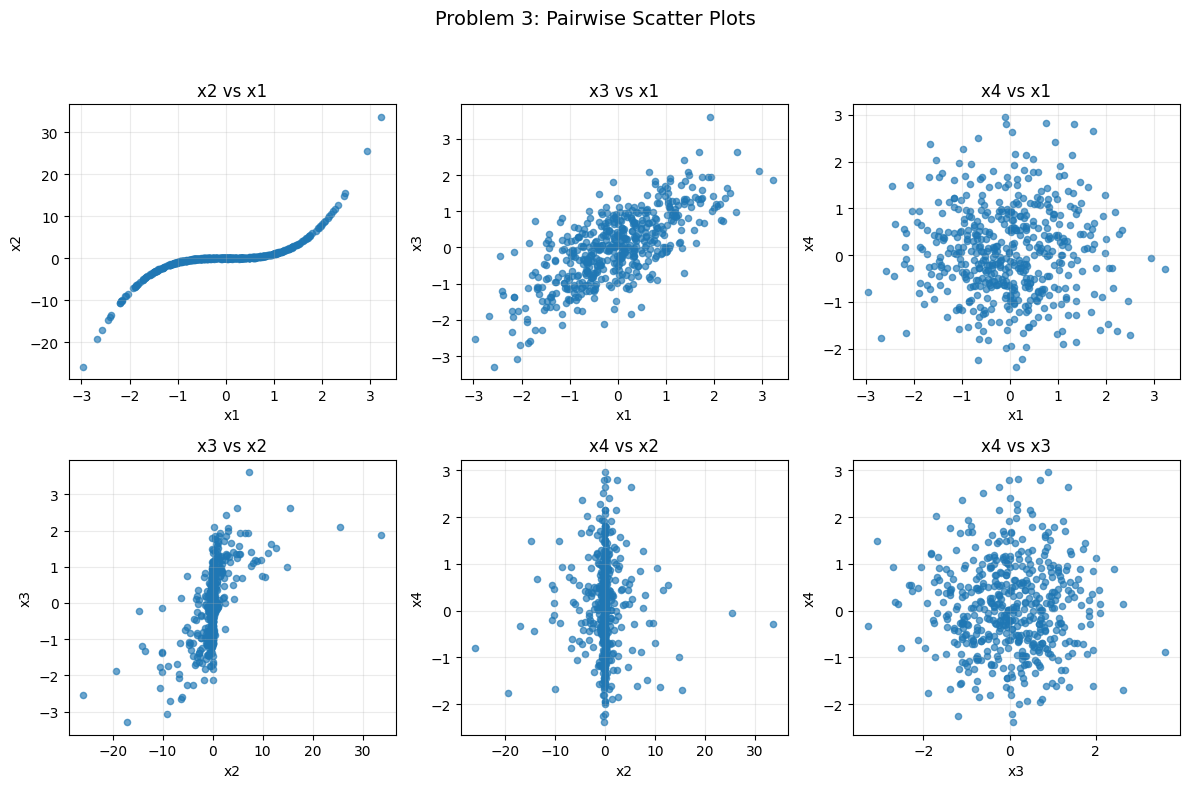

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

data = pd.read_csv("problem3.csv")

cols = ["x1", "x2", "x3", "x4"]

pairs = list(combinations(cols, 2))

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):

    ax.scatter(
        data[x_col],
        data[y_col],
        alpha=0.65,
        s=20
    )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    ax.set_title(
        f"{y_col} vs {x_col}"
    )

    ax.grid(alpha=0.25)

plt.suptitle(
    "Problem 3: Pairwise Scatter Plots",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.show()

In [6]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# Problem 3: Load data
# --------------------------------------------------

data = pd.read_csv("problem3.csv")

cols = ["x1", "x2", "x3", "x4"]

df = data[cols].dropna()


# ==================================================
# 1. Pearson Correlation Matrix
# ==================================================

pearson_corr = df.corr(method="pearson")


# ==================================================
# 2. Spearman Correlation Matrix
# ==================================================


spearman_corr = df.corr(method="spearman")


# ==================================================
# 3. Absolute Difference Matrix
# ==================================================

# Measure disagreement by:
#
# | Pearson correlation - Spearman correlation |

difference_matrix = np.abs(
    pearson_corr - spearman_corr
)


# ==================================================
# 4. Find Largest and Smallest Pairwise Differences
# ==================================================
#
# Only use unique variable pairs.


pair_results = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):

        var1 = cols[i]
        var2 = cols[j]

        pearson_value = pearson_corr.loc[var1, var2]
        spearman_value = spearman_corr.loc[var1, var2]

        gap = abs(
            pearson_value - spearman_value
        )

        pair_results.append({
            "Pair": f"{var1}-{var2}",
            "Pearson": pearson_value,
            "Spearman": spearman_value,
            "Absolute Difference": gap
        })


# Convert results into a DataFrame
pair_results_df = pd.DataFrame(pair_results)

# Sort from largest disagreement to smallest
pair_results_df = pair_results_df.sort_values(
    by="Absolute Difference",
    ascending=False
).reset_index(drop=True)


# ==================================================
# 5. Print Results
# ==================================================


print("\n1. Pearson Correlation Matrix")
print(
    pearson_corr.round(6)
)


print("\n2. Spearman Correlation Matrix")
print(
    spearman_corr.round(6)
)


print("\n3. Pairwise Comparison")

print(
    pair_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# --------------------------------------------------
# Largest disagreement
# --------------------------------------------------

largest = pair_results_df.iloc[0]

print("\n4. Largest Pearson-Spearman Difference")
print(f"Pair:                   {largest['Pair']}")
print(f"Pearson correlation:    {largest['Pearson']:.6f}")
print(f"Spearman correlation:   {largest['Spearman']:.6f}")
print(
    f"Absolute difference:    "
    f"{largest['Absolute Difference']:.6f}"
)


# --------------------------------------------------
# Smallest disagreement
# --------------------------------------------------

smallest = pair_results_df.iloc[-1]

print("\n5. Smallest Pearson-Spearman Difference")
print(f"Pair:                   {smallest['Pair']}")
print(f"Pearson correlation:    {smallest['Pearson']:.6f}")
print(f"Spearman correlation:   {smallest['Spearman']:.6f}")
print(
    f"Absolute difference:    "
    f"{smallest['Absolute Difference']:.6f}"
)


1. Pearson Correlation Matrix
          x1        x2        x3        x4
x1  1.000000  0.799092  0.719467 -0.004680
x2  0.799092  1.000000  0.587614 -0.020923
x3  0.719467  0.587614  1.000000 -0.008605
x4 -0.004680 -0.020923 -0.008605  1.000000

2. Spearman Correlation Matrix
          x1        x2        x3        x4
x1  1.000000  0.971930  0.683910  0.000189
x2  0.971930  1.000000  0.667422 -0.001131
x3  0.683910  0.667422  1.000000 -0.002422
x4  0.000189 -0.001131 -0.002422  1.000000

3. Pairwise Comparison
 Pair   Pearson  Spearman  Absolute Difference
x1-x2  0.799092  0.971930             0.172838
x2-x3  0.587614  0.667422             0.079808
x1-x3  0.719467  0.683910             0.035557
x2-x4 -0.020923 -0.001131             0.019792
x3-x4 -0.008605 -0.002422             0.006183
x1-x4 -0.004680  0.000189             0.004869

4. Largest Pearson-Spearman Difference
Pair:                   x1-x2
Pearson correlation:    0.799092
Spearman correlation:   0.971930
Absolute differenc